In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightkurve as lk

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from fgivenx import plot_contours, plot_lines, plot_dkl
from anesthetic import read_chains

import nestar.ARIMA_ns as ARIMA_ns
from nestar.ARIMA import ARIMA_fast, ARIMA_forecast
from nestar.priors import normal_prior
from nestar.model_comparison_utils import ARIMA_model_comparison
from nestar import arima_results as ar

/Users/ajinkya/myenv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


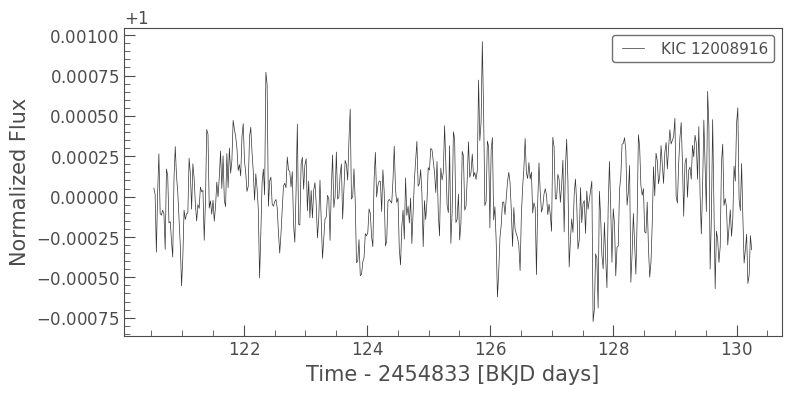

In [3]:
all_lcs = lk.search_lightcurve('KIC 12008916')
lc = all_lcs[0].download()
lc = lc.remove_outliers(sigma=5).normalize()
lc.plot()
plt.show()

In [4]:
import numpy as np
flux_var = np.array(lc['flux'].value,dtype=np.float64)
flux_err_var = np.array(lc['flux_err'].value)
time_var = np.array(lc['time'].value)

In [5]:
from model_comparison_utils import stationarity_test
stationarity_test(flux_var)

Results of Dickey-Fuller Test:
Test Statistic                  -4.620294
p-value                          0.000118
#Lags Used                       9.000000
Number of Observations Used    459.000000
Critical Value (1%)             -3.444677
Critical Value (5%)             -2.867857
Critical Value (10%)            -2.570135
dtype: float64
Series stationary acc to ADF Test
Results of KPSS Test:
Test Statistic            0.100269
p-value                   0.100000
Lags Used                10.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
Series stationarity acc to KPSS test


/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_comparison_utils.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")
/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_comparison_utils.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if kpss_output[1] < 0.05:


(None, None)

In [ ]:
#logPs = ARIMA_model_comparison(data=flux_var,max_p=10,max_q=10,d=0,num_live=200,num_delete=50,seed=50,mu_mean=1,mu_scale=5,meas_sigma=None,file_name='Heatmap Data/KIC_12008916_evidences_max.txt')
#logPs.run()

/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_4355/2002898276.py:1: UserWarning: 'Heatmap Data/KIC_12008916_evidences_max.txt' already exists and will be overwritten by this run. If you meant to keep it, rename/move it (or change file_name) before calling .run().
  logPs = ARIMA_model_comparison(data=flux_var,max_p=10,max_q=10,d=0,num_live=200,num_delete=50,seed=50,mu_mean=1,mu_scale=5,meas_sigma=None,file_name='Heatmap Data/KIC_12008916_evidences_max.txt')
/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_4355/2002898276.py:2: UserWarning: 'Heatmap Data/KIC_12008916_evidences_max.txt' already exists and will be overwritten by this run. 
  logPs.run()


Running Nested Sampling for fitting ARIMA (0, 0, 1) model...


Dead points: 6600 dead points [00:06, 1074.14 dead points/s]


Finished Nested Sampling with a total runtime of : 6.70 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 0, 1) : 3277.333739095237 ; Error : 0.40893023379794297
V : 0.68087 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.384
Highest Evidence so far : 3277.333739095237 for order : (0, 0, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 0, 2) model...


Dead points: 7000 dead points [00:09, 709.31 dead points/s]


...

Dead points: 24400 dead points [21:49, 18.63 dead points/s]


Finished Nested Sampling with a total runtime of : 1311.65 seconds
----------------------x-------------------x---------------------x------
Evidence for (9, 0, 8) : 3210.8088494916265 ; Error : 0.8695817045463881
V : 6.48508430609598e-07 ; D0 Occam : -33.898 ; Net prior-volume effect : -19.649
Highest Evidence so far : 3295.5911148755163 for order : (0, 0, 4)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (9, 0, 9) model...
Acceptance rate: 0.0000, Total drawn: 400000
Acceptance rate: 0.0000, Total drawn: 600000
Acceptance rate: 0.0000, Total drawn: 800000
Acceptance rate: 0.0000, Total drawn: 1000000
Acceptance rate: 0.0000, Total drawn: 1200000
Acceptance rate: 0.0000, Total drawn: 1400000
Acceptance rate: 0.0000, Total drawn: 1600000
Acceptance rate: 0.0000, Total drawn: 1800000
Acceptance rate: 0.0000, Total drawn: 2000000
Acceptance rate: 0.0000, Total drawn: 2200000
Acceptance rate: 0.0000, Total drawn: 2400000
Acc

Dead points: 19750 dead points [20:59, 15.68 dead points/s]


Finished Nested Sampling with a total runtime of : 1261.40 seconds
----------------------x-------------------x---------------------x------
Evidence for (9, 0, 9) : 3236.25923156235 ; Error : 0.7383491077657639
V : 2.015316404675534e-07 ; D0 Occam : -34.034 ; Net prior-volume effect : -18.617
Highest Evidence so far : 3295.5911148755163 for order : (0, 0, 4)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (9, 0, 10) model...
Acceptance rate: 0.0000, Total drawn: 400000
Acceptance rate: 0.0000, Total drawn: 600000
Acceptance rate: 0.0000, Total drawn: 800000
Acceptance rate: 0.0000, Total drawn: 1000000
Acceptance rate: 0.0000, Total drawn: 1200000
Acceptance rate: 0.0000, Total drawn: 1400000
Acceptance rate: 0.0000, Total drawn: 1600000
Acceptance rate: 0.0000, Total drawn: 1800000
Acceptance rate: 0.0000, Total drawn: 2000000
Acceptance rate: 0.0000, Total drawn: 2200000
Acceptance rate: 0.0000, Total drawn: 2400000
Acc

KeyboardInterrupt: 

In [25]:
logP_pacf = ARIMA_model_comparison(data=flux_var,max_p=10,max_q=10,d=0,num_live=200,num_delete=40,seed=33,mu_mean=1,mu_scale=5,meas_sigma=None,file_name='Heatmap Data/KIC_12008916_evidences_pacf.txt',prior_type="pacf")
logP_pacf.run()

/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_45328/4162698651.py:1: UserWarning: 'Heatmap Data/KIC_12008916_evidences_pacf.txt' already exists and will be overwritten by this run. If you meant to keep it, rename/move it (or change file_name) before calling .run().
  logP_pacf = ARIMA_model_comparison(data=flux_var,max_p=10,max_q=10,d=0,num_live=200,num_delete=40,seed=33,mu_mean=1,mu_scale=5,meas_sigma=None,file_name='Heatmap Data/KIC_12008916_evidences_pacf.txt',prior_type="pacf")
/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_45328/4162698651.py:2: UserWarning: 'Heatmap Data/KIC_12008916_evidences_pacf.txt' already exists and will be overwritten by this run. 
  logP_pacf.run()


Running Nested Sampling for fitting ARIMA (0, 0, 1) model...


Dead points: 6680 dead points [00:03, 2007.19 dead points/s]


Finished Nested Sampling with a total runtime of : 3.72 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 0, 1) : 3277.8855131802966 ; Error : 0.40975331004564114
V : 1.0 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.000
Highest Evidence so far : 3277.8855131802966 for order : (0, 0, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 0, 2) model...


Dead points: 7160 dead points [00:05, 1366.31 dead points/s]


...

Finished Nested Sampling with a total runtime of : 126.12 seconds
----------------------x-------------------x---------------------x------
Evidence for (2, 0, 8) : 3281.508886839762 ; Error : 0.5662933500426671
V : 1.0 ; D0 Occam : -5.317 ; Net prior-volume effect : -5.317
Highest Evidence so far : 3295.0498605457055 for order : (0, 0, 4)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (2, 0, 9) model...


Dead points: 14760 dead points [02:47, 88.25 dead points/s]


Finished Nested Sampling with a total runtime of : 168.03 seconds
----------------------x-------------------x---------------------x------
Evidence for (2, 0, 9) : 3264.725877903591 ; Error : 0.6546194819301269
V : 1.0 ; D0 Occam : -9.338 ; Net prior-volume effect : -9.338
Highest Evidence so far : 3295.0498605457055 for order : (0, 0, 4)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (2, 0, 10) model...


Dead points: 1960 dead points [00:25, 77.73 dead points/s]


KeyboardInterrupt: 

In [6]:
heatmap_data = ar.EvidenceResults("Heatmap Data/KIC_evidences_reconstructed.txt",max_p=9)
log_posterior = heatmap_data.log_posteriors
log_post_err = heatmap_data.evidence_err
print(f"Best fit model ARIMA(0,0,4) with logP:{max(log_posterior)} and error:{log_post_err[np.argmax(log_posterior)]}")
heatmap_data.cumulative_posterior_mass(5)

Best fit model ARIMA(0,0,4) with logP:-0.802582780175271 and error:0.465044657802633


{'n': 5,
 'top_orders': [(0, 0, 4), (0, 0, 9), (0, 0, 5), (0, 0, 10), (0, 0, 8)],
 'individual_mass': array([0.44816994, 0.35757688, 0.06590007, 0.04659047, 0.03933113]),
 'cumulative_mass': 0.9575684937947431}

In [26]:
##Tau sensitivity checks around best-fit neighbour and extreme models:
orders = [(0,0,4),(0,0,5),(0,0,3),(1,0,3),(1,0,4),(1,0,5),(2,0,3),(2,0,4),(2,0,5)]

tau_evidences = []
tau_err = []
for tau in [1.7,15]:
 neighbour_evidences = []
 neighbour_evidences_err = []
 for order in orders:
    test_model = ARIMA_ns.ARIMA_Nested_Sampler(data=flux_var,order=order,num_live=100,num_delete=50,mu_mean=0,mu_scale=tau,seed=30)
    evidence = test_model.log_evidence
    neighbour_evidences.append(evidence)
    neighbour_evidences_err.append(test_model.log_evidence_err)
 tau_evidences.append(neighbour_evidences)
 tau_err.append(neighbour_evidences_err)

Running Nested Sampling for fitting ARIMA (0, 0, 4) model...


Dead points: 3300 dead points [00:08, 375.00 dead points/s]


Finished Nested Sampling with a total runtime of : 9.47 seconds
Running Nested Sampling for fitting ARIMA (0, 0, 5) model...


Dead points: 3400 dead points [00:13, 260.59 dead points/s]


Finished Nested Sampling with a total runtime of : 13.82 seconds
Running Nested Sampling for fitting ARIMA (0, 0, 3) model...


...

Finished Nested Sampling with a total runtime of : 38.02 seconds
Running Nested Sampling for fitting ARIMA (2, 0, 4) model...


Dead points: 5350 dead points [00:47, 111.54 dead points/s]


Finished Nested Sampling with a total runtime of : 48.41 seconds
Running Nested Sampling for fitting ARIMA (2, 0, 5) model...


Dead points: 4550 dead points [00:51, 87.98 dead points/s] 


Finished Nested Sampling with a total runtime of : 52.26 seconds


In [27]:
print(tau_evidences[0])
print(tau_err[0])
print(tau_evidences[1])
print(tau_err[1])

[np.float64(3296.1385845960576), np.float64(3294.357596422162), np.float64(3277.1014620520905), np.float64(3278.92769615724), np.float64(3290.106624907142), np.float64(3287.982394046855), np.float64(3272.9713315724343), np.float64(3271.737843317454), np.float64(3273.114859164635)]
[np.float64(0.7576958376016262), np.float64(0.71545480165257), np.float64(0.6635631090669082), np.float64(0.7115579079581104), np.float64(0.7174199060665326), np.float64(0.7704595316764642), np.float64(0.9565161888633259), np.float64(0.9294631901041053), np.float64(0.9042396575057418)]
[np.float64(3293.167105794469), np.float64(3292.2867185222167), np.float64(3274.0115345638196), np.float64(3273.0030364643817), np.float64(3284.9849408095756), np.float64(3280.7668036379237), np.float64(3261.976919653249), np.float64(3267.7045817328444), np.float64(3279.344045808215)]
[np.float64(0.7945319235222205), np.float64(0.714283245952098), np.float64(0.7620624795593045), np.float64(0.8447431787085562), np.float64(0.8286

In [ ]:
np.argmax(tau_evidences[0])
np.argmax(tau_evidences[1]) #model stable against tau

np.int64(0)

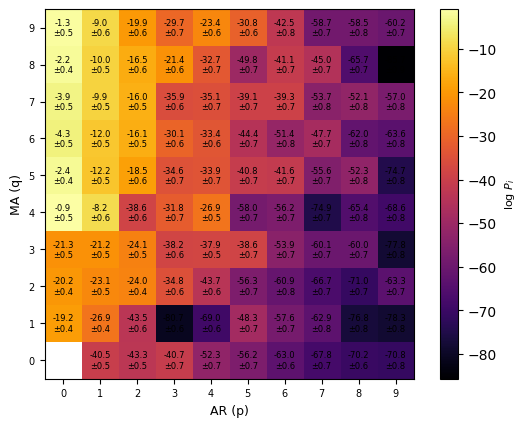

In [13]:
KIC_heatmap = ar.EvidenceResults("Heatmap Data/KIC_12008916_evidences_max.txt",max_p=9,max_q=9)
KIC_heatmap.plot_evidence_heatmap()

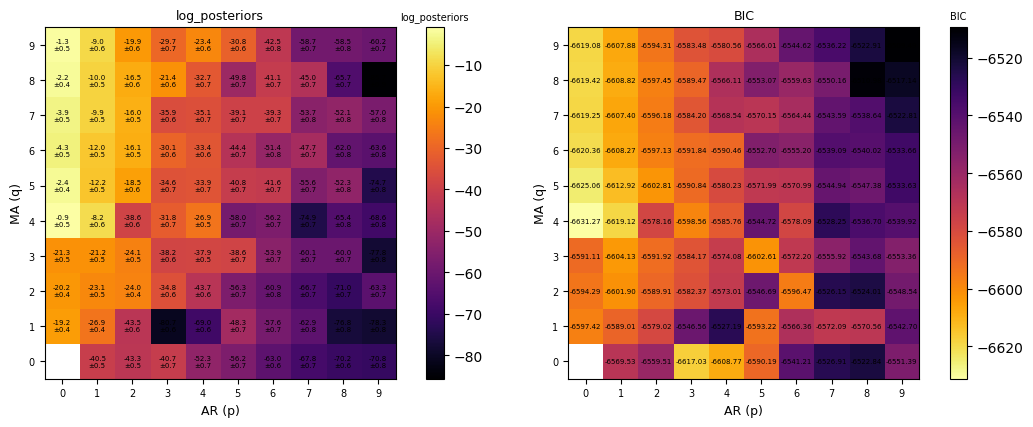

In [ ]:
KIC_heatmap.compare(quantity2="BIC") #compare with BIC

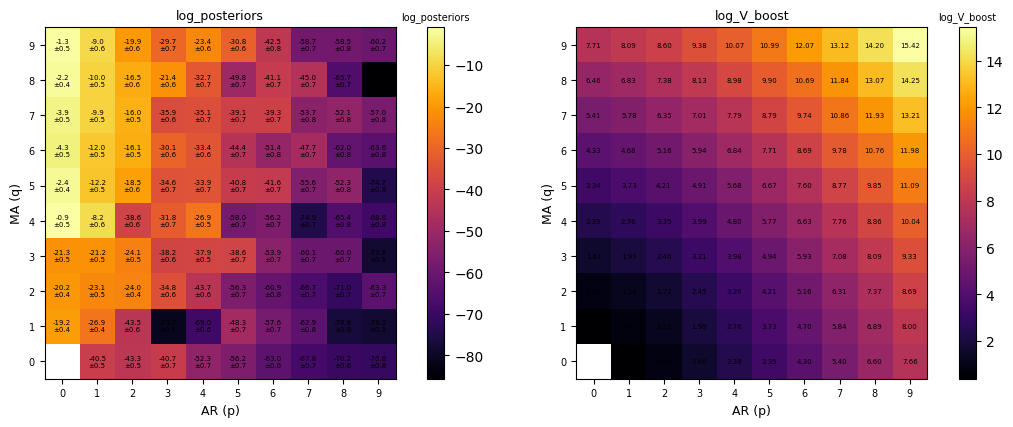

In [17]:
KIC_heatmap.compare(quantity2="log_V_boost")

In [ ]:
KIC_heatmap.prior_volume_report((0,0,9),(0,0,4)) #how much of prefernece for (0,0,9) is from prior volume effects

{'order_of_interest': (0, 0, 9),
 'baseline_order': (0, 0, 4),
 'raw_log_posterior_delta': -0.40218284874435994,
 'log_V_boost_delta': 5.324519578108285,
 'd0_occam_delta': 0.0,
 'net_prior_volume_delta': 5.324519578108285,
 'likelihood_only_delta': -5.726702426852645,
 'fraction_of_raw_delta_from_prior_volume': -13.239051826132737}

In [ ]:
model_09 = ARIMA_ns.ARIMA_Nested_Sampler(data=flux_var,meas_sigma=None,order=(0,0,9),num_live=1000,num_delete=50,mu_scale=5,mu_mean=1,seed=30)
model_04 = ARIMA_ns.ARIMA_Nested_Sampler(data=flux_var,meas_sigma=None,order=(0,0,4),num_live=1000,num_delete=50,mu_scale=5,mu_mean=1,seed=30)

Running Nested Sampling for fitting ARIMA (0, 0, 9) model...
Acceptance rate: 0.0005, Total drawn: 2000000
Acceptance rate: 0.0005, Total drawn: 3000000


Dead points: 53400 dead points [08:19, 106.81 dead points/s]


Finished Nested Sampling with a total runtime of : 500.87 seconds
Running Nested Sampling for fitting ARIMA (0, 0, 4) model...


Dead points: 43950 dead points [01:26, 510.55 dead points/s]


Finished Nested Sampling with a total runtime of : 87.19 seconds


In [30]:
kic12008916_posteriors = ar.PosteriorResults("NS Chains/old/KIC_12008916_samples.csv",train_data=flux_var,deterministic=False)
insample_fig = kic12008916_posteriors.insample_forecast(training_time=time_var,n_samples=5000,seed=33,ms=1,capsize=2)
plt.show()

TypeError: PosteriorResults.__init__() got an unexpected keyword argument 'deterministic'

In [ ]:
point_est = kic12008916_posteriors.point_estimate_forecast(estimate='mean')
residual = point_est["residuals"]

In [24]:
sm.stats.acorr_ljungbox(residual, lags=np.arange(10,21,1), return_df=True,model_df=4)

,lb_stat,lb_pvalue
10,10.175043,0.117471
11,12.224464,0.093415
12,12.224476,0.141466
13,12.373774,0.193048
14,12.741636,0.238478
15,12.936200,0.297516
16,16.068109,0.188136
17,16.541489,0.221121
18,16.618309,0.277089
19,17.755248,0.275751
